# 04 Three-Group Similarity

Compare Control, LD, and NMDA together instead of only pairwise panel heatmaps.

Outputs:
- Control-referenced LD/NMDA heatmaps
- NMDA-minus-LD delta heatmaps
- three-condition pseudobulk centroid PCA

In [1]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
from scipy import sparse
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
sc.settings.verbosity = 2

cwd = Path.cwd().resolve()
REPO_ROOT = cwd if (cwd / "config" / "config.yaml").exists() else cwd.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from fidelity_utils import (
    ensure_output_dirs,
    finite_similarity,
    get_expression_source,
    load_config,
    mean_expression_by_mask,
    normalize_labels,
    resolve_metadata_columns,
    retinal_cell_type_mask,
)

print("Repo root:", REPO_ROOT)
print("scanpy", sc.__version__)
print("anndata", ad.__version__)

Repo root: /Users/louis/Desktop/lab/code/zebrafish-retina-similarity-analysis
scanpy 1.9.3
anndata 0.8.0


## Load Data

In [2]:
config = load_config(REPO_ROOT / "config" / "config.yaml")
tables_dir, figures_dir = ensure_output_dirs(config)

h5ad_path = Path(config["data"]["h5ad_path"])
if not h5ad_path.is_absolute():
    h5ad_path = REPO_ROOT / h5ad_path

adata = sc.read_h5ad(h5ad_path)
condition_column, cell_type_column = resolve_metadata_columns(adata, config)
expression, var_names, expression_source = get_expression_source(adata, config)

print(adata)
print("condition_column:", condition_column)
print("cell_type_column:", cell_type_column)
print("expression_source:", expression_source)

AnnData object with n_obs × n_vars = 160875 × 24597
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'renamed_samples', 'predicted_doublets', 'leiden', 'celltype'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'celltype_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'renamed_samples_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'
condition_column: renamed_samples
cell_type_column: celltype
expression_source: raw.X


In [3]:
obs = adata.obs.copy()
obs["_condition"] = normalize_labels(obs[condition_column])
obs["_cell_type"] = normalize_labels(obs[cell_type_column])

control_label = config["metadata"].get("control_label", "Control")
injury_labels = config["metadata"].get("injury_labels", ["LD", "NMDA"])
condition_order = [control_label] + list(injury_labels)
metrics = config["analysis"].get("similarity_metrics", ["pearson", "spearman", "cosine"])
gene_cfg = config["analysis"].get("gene_sets", {})
hvg_flavor = gene_cfg.get("hvg_flavor", "seurat")
min_mean_expression = float(gene_cfg.get("min_mean_expression", 0.0))

GENE_SETS = ["shared_expressed", "hvg_1000", "hvg_2000"]

retinal_mask = retinal_cell_type_mask(obs, "_cell_type", config).to_numpy()
cell_types = sorted(obs.loc[retinal_mask, "_cell_type"].dropna().unique())
cell_types

['AC', 'BC', 'Cones', 'HC', 'MG', 'MGPC', 'PR precursors', 'RGC', 'Rod']

## Helper Functions

In [4]:
def expressed_gene_mask(matrix, min_mean_expression=0.0):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
    else:
        means = np.asarray(matrix).mean(axis=0).ravel()
    return means > min_mean_expression


def variance_gene_indices(matrix, n_top):
    if sparse.issparse(matrix):
        means = np.asarray(matrix.mean(axis=0)).ravel()
        means_sq = np.asarray(matrix.power(2).mean(axis=0)).ravel()
        variances = means_sq - np.square(means)
    else:
        variances = np.asarray(matrix).var(axis=0)
    n = min(int(n_top), matrix.shape[1])
    return np.argsort(variances)[-n:]


def scanpy_hvg_gene_indices(matrix, n_top, flavor="seurat"):
    n = min(int(n_top), matrix.shape[1])
    if n <= 0:
        return np.array([], dtype=int)
    try:
        hvg_adata = ad.AnnData(X=matrix.copy())
        sc.pp.highly_variable_genes(hvg_adata, n_top_genes=n, flavor=flavor, inplace=True)
        indices = np.where(hvg_adata.var["highly_variable"].to_numpy())[0]
        if indices.size > 0:
            return indices[:n]
    except Exception as exc:
        print(f"Scanpy HVG failed for n_top={n_top}; using variance fallback: {exc}")
    return variance_gene_indices(matrix, n)


def build_gene_sets(expression, retinal_mask, requested_gene_sets):
    retinal_expression = expression[retinal_mask]
    expressed_idx = np.where(expressed_gene_mask(retinal_expression, min_mean_expression))[0]
    selected = {}
    if "shared_expressed" in requested_gene_sets:
        selected["shared_expressed"] = expressed_idx
    for gene_set in requested_gene_sets:
        if gene_set.startswith("hvg_"):
            n_top = int(gene_set.split("_", 1)[1])
            local_idx = scanpy_hvg_gene_indices(expression[retinal_mask][:, expressed_idx], n_top, hvg_flavor)
            selected[gene_set] = expressed_idx[local_idx]
    return selected

## Compute Centroids And Control-Referenced Similarities

In [5]:
gene_sets = build_gene_sets(expression, retinal_mask, GENE_SETS)
records = []
centroid_records = []

for gene_set, gene_idx in gene_sets.items():
    centroids = {}
    for cell_type in cell_types:
        for condition in condition_order:
            group_mask = (obs["_cell_type"] == cell_type).to_numpy() & (obs["_condition"] == condition).to_numpy()
            if group_mask.sum() == 0:
                continue
            centroid = mean_expression_by_mask(expression[:, gene_idx], group_mask)
            centroids[(cell_type, condition)] = centroid
            centroid_records.append(
                {
                    "gene_set": gene_set,
                    "cell_type": cell_type,
                    "condition": condition,
                    "n_cells": int(group_mask.sum()),
                    **{f"gene_{i}": value for i, value in enumerate(centroid)},
                }
            )

        for condition_b in injury_labels:
            if (cell_type, control_label) not in centroids or (cell_type, condition_b) not in centroids:
                continue
            for metric in metrics:
                records.append(
                    {
                        "cell_type": cell_type,
                        "comparison": f"{control_label}_vs_{condition_b}",
                        "condition_a": control_label,
                        "condition_b": condition_b,
                        "metric": metric,
                        "gene_set": gene_set,
                        "n_genes": int(len(gene_idx)),
                        "similarity": finite_similarity(centroids[(cell_type, control_label)], centroids[(cell_type, condition_b)], metric),
                    }
                )

summary = pd.DataFrame(records)
centroids = pd.DataFrame(centroid_records)
summary.to_csv(tables_dir / "three_group_control_referenced_similarity.csv", index=False)
centroids.to_csv(tables_dir / "three_group_centroids.csv", index=False)
summary.head()

If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)
If you pass `n_top_genes`, all cutoffs are ignored.
extracting highly variable genes
    finished (0:00:02)


,cell_type,comparison,condition_a,condition_b,metric,gene_set,n_genes,similarity
0,AC,Control_vs_LD,Control,LD,pearson,shared_expressed,24579,0.905403
1,AC,Control_vs_LD,Control,LD,spearman,shared_expressed,24579,0.916177
2,AC,Control_vs_LD,Control,LD,cosine,shared_expressed,24579,0.924181
3,AC,Control_vs_NMDA,Control,NMDA,pearson,shared_expressed,24579,0.905366
4,AC,Control_vs_NMDA,Control,NMDA,spearman,shared_expressed,24579,0.926608


## Control-Referenced LD/NMDA Heatmap

In [6]:
PLOT_METRIC = "pearson"
PLOT_GENE_SET = "hvg_1000"

plot_summary = summary[(summary["metric"] == PLOT_METRIC) & (summary["gene_set"] == PLOT_GENE_SET)]
control_heat = plot_summary.pivot_table(index="cell_type", columns="condition_b", values="similarity", observed=False)
control_heat = control_heat[[col for col in ["LD", "NMDA"] if col in control_heat.columns]]
control_heat

condition_b,LD,NMDA
cell_type,,
AC,0.796067,0.795501
BC,0.469123,0.457857
Cones,0.813880,0.822477
HC,0.789104,0.748408
MG,0.851711,0.846643
MGPC,0.678544,0.702413
PR precursors,0.672120,0.692345
RGC,0.793642,0.813710
Rod,0.709483,0.366290


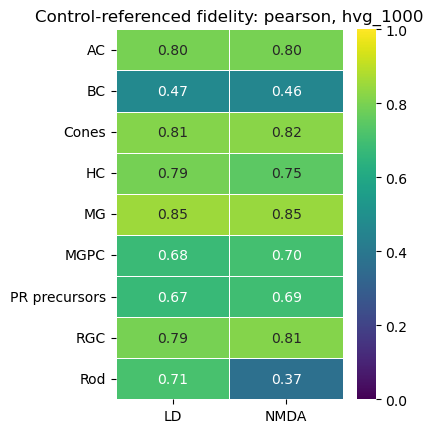

In [7]:
fig, ax = plt.subplots(figsize=(4.2, max(3.2, 0.36 * len(control_heat) + 1.2)))
sns.heatmap(control_heat, vmin=0, vmax=1, cmap="viridis", annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Control-referenced fidelity: {PLOT_METRIC}, {PLOT_GENE_SET}")
fig.tight_layout()
fig.savefig(figures_dir / f"three_group_control_referenced_{PLOT_METRIC}_{PLOT_GENE_SET}.png", dpi=300, bbox_inches="tight")

## Delta Heatmap: NMDA Minus LD

In [8]:
delta = pd.DataFrame({"NMDA_minus_LD": control_heat["NMDA"] - control_heat["LD"]})
delta.to_csv(tables_dir / f"three_group_delta_nmda_minus_ld_{PLOT_METRIC}_{PLOT_GENE_SET}.csv")
delta

,NMDA_minus_LD
cell_type,
AC,-0.000566
BC,-0.011266
Cones,0.008597
HC,-0.040697
MG,-0.005068
MGPC,0.023868
PR precursors,0.020225
RGC,0.020068
Rod,-0.343192


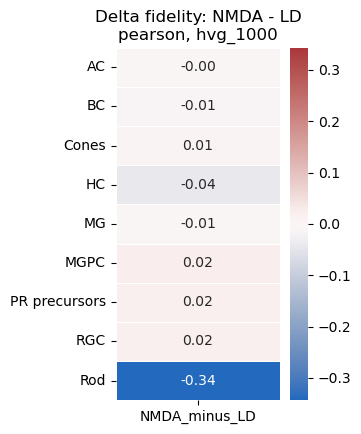

In [9]:
max_abs = max(float(np.nanmax(np.abs(delta.to_numpy()))), 0.01)
fig, ax = plt.subplots(figsize=(3.6, max(3.2, 0.36 * len(delta) + 1.2)))
sns.heatmap(delta, vmin=-max_abs, vmax=max_abs, cmap="vlag", annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"Delta fidelity: NMDA - LD\n{PLOT_METRIC}, {PLOT_GENE_SET}")
fig.tight_layout()
fig.savefig(figures_dir / f"three_group_delta_nmda_minus_ld_{PLOT_METRIC}_{PLOT_GENE_SET}.png", dpi=300, bbox_inches="tight")

## Three-Condition Centroid PCA

In [10]:
pca_data = centroids[centroids["gene_set"] == PLOT_GENE_SET].copy()
feature_cols = [col for col in pca_data.columns if col.startswith("gene_") and col[5:].isdigit()]
feature_cols = [col for col in feature_cols if pca_data[col].notna().all()]
x = StandardScaler().fit_transform(pca_data[feature_cols].to_numpy())
pca = PCA(n_components=2, random_state=0)
coords = pca.fit_transform(x)
pca_data["PC1"] = coords[:, 0]
pca_data["PC2"] = coords[:, 1]
pca_data[["cell_type", "condition", "n_cells", "PC1", "PC2"]].head()

,cell_type,condition,n_cells,PC1,PC2
27,AC,Control,13751,37.631199,11.912179
28,AC,LD,342,27.786409,-11.284543
29,AC,NMDA,1424,25.862848,-9.591730
30,BC,Control,62885,2.754975,19.015167
31,BC,LD,545,-5.305375,-1.901897


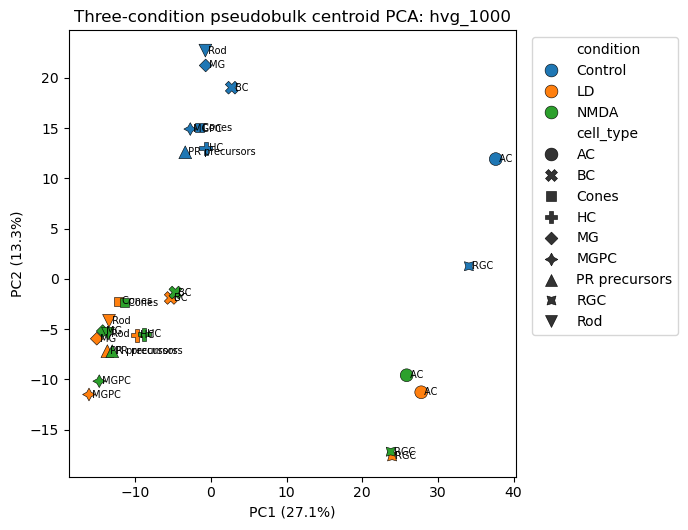

In [11]:
fig, ax = plt.subplots(figsize=(7, 5.4))
sns.scatterplot(data=pca_data, x="PC1", y="PC2", hue="condition", style="cell_type", s=85, edgecolor="black", linewidth=0.4, ax=ax)
for _, row in pca_data.iterrows():
    ax.text(row["PC1"], row["PC2"], f" {row['cell_type']}", fontsize=7, va="center")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
ax.set_title(f"Three-condition pseudobulk centroid PCA: {PLOT_GENE_SET}")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()
fig.savefig(figures_dir / f"three_group_centroid_pca_{PLOT_GENE_SET}.png", dpi=300, bbox_inches="tight")

## Script Equivalent

```bash
python scripts/three_group_similarity.py --config config/config.yaml
```